In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

file = '../Scenario_Analysis.xlsx'

# --- Load and shape data ---
df = pd.read_excel(file, sheet_name='ObjFunc')

# first 6 scenarios, set Scenario as index
df = df.iloc[:6].set_index('Scenario')

# keep only from Buy_Electricity to Total Profit (adjust first col name if needed)
df = df.loc[:, 'Buy_Electricity':'Total Profit']

# remove columns that dont contribute much
remove_cols = ['Variable_OM_ElectricStorage', 'Variable_OM_Boiler']
df = df.drop(columns=remove_cols)

df

,Buy_Electricity,Buy_NatGas,Sell_Electricity,Sell_H2,Variable_OM_WindTurbine,Variable_OM_Digester,Variable_OM_BiogasUpgrade,Variable_OM_CO2Compressor,Total Profit
Scenario,,,,,,,,,
Baseline,-290242.670542,-206149.000254,7.139412e+06,0.000000,-499860.735450,-376900.615579,-214285.714286,0.0,5.539800e+06
NoStorageCO2,-293123.048608,-206218.226026,7.134445e+06,0.000000,-499816.407069,-376900.615579,-214285.714286,0.0,5.531926e+06
NoStorageALL,-300138.873774,-206716.878023,6.669745e+06,0.000000,-496855.763813,-376900.615579,-214285.714286,0.0,5.062644e+06
H2,-367387.503209,-206101.718021,6.875620e+06,369100.658445,-499860.735450,-376900.615579,-214285.714286,0.0,5.568011e+06
BioFixed,-312441.066448,-402875.067246,7.012883e+06,0.000000,-499949.393842,-835463.031201,-475000.000000,0.0,4.463370e+06
CO2Trans,-289496.867530,-206139.422544,7.138843e+06,0.000000,-499860.735450,-376900.615579,-214285.714286,-96364.8,5.443622e+06


In [2]:

# rename columns
df = df.rename(columns={
    'Buy_Electricity': 'Electricity Purchase',
    'Buy_NatGas': 'Natural Gas Purchase',
    'Sell_Electricity': 'Electricity Sales',
    'Sell_H2': 'Hydrogen Sales',
    'Variable_OM_WindTurbine': 'O&M Wind Turbine',
    'Variable_OM_Digester': 'O&M Digester',
    'Variable_OM_BiogasUpgrade': 'O&M Biogas Upgrade',
    'Variable_OM_CO2Compressor': 'Transportation',
    'Total Profit': 'Profit'
})

profit_col = 'Profit'
bar_cols = [c for c in df.columns if c != profit_col]

# scaling for nicer units
scale = 1000000
df_plot = df / scale

df_plot

,Electricity Purchase,Natural Gas Purchase,Electricity Sales,Hydrogen Sales,O&M Wind Turbine,O&M Digester,O&M Biogas Upgrade,Transportation,Profit
Scenario,,,,,,,,,
Baseline,-0.290243,-0.206149,7.139412,0.000000,-0.499861,-0.376901,-0.214286,0.000000,5.539800
NoStorageCO2,-0.293123,-0.206218,7.134445,0.000000,-0.499816,-0.376901,-0.214286,0.000000,5.531926
NoStorageALL,-0.300139,-0.206717,6.669745,0.000000,-0.496856,-0.376901,-0.214286,0.000000,5.062644
H2,-0.367388,-0.206102,6.875620,0.369101,-0.499861,-0.376901,-0.214286,0.000000,5.568011
BioFixed,-0.312441,-0.402875,7.012883,0.000000,-0.499949,-0.835463,-0.475000,0.000000,4.463370
CO2Trans,-0.289497,-0.206139,7.138843,0.000000,-0.499861,-0.376901,-0.214286,-0.096365,5.443622


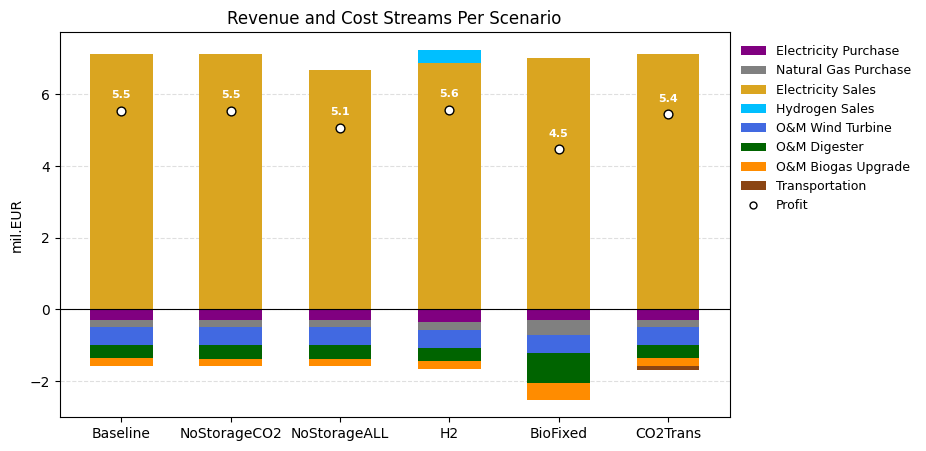

In [3]:

colors = {
    'Electricity Purchase':      'purple',
    'Natural Gas Purchase':        'grey',
    'Electricity Sales':         'goldenrod',
    'Hydrogen Sales':            'deepskyblue',
    'O&M Wind Turbine':          'royalblue',
    'O&M Digester':              'darkgreen',
    'O&M Biogas Upgrade':        'darkorange',
    'Transportation':            'saddlebrown',
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_plot))*0.7
width = 0.4

used_labels = set()

for i, (scenario, row) in enumerate(df_plot.iterrows()):
    bottom_pos = 0
    bottom_neg = 0

    for col in bar_cols:
        value = row[col]
        if value == 0:
            continue

        # label only the first non-zero occurrence of each column
        label = col if col not in used_labels else None

        if value > 0:
            ax.bar(
                x[i],
                value,
                width,
                bottom=bottom_pos,
                label=label,
                color=colors[col]
            )
            bottom_pos += value
        else:
            ax.bar(
                x[i],
                value,
                width,
                bottom=bottom_neg,
                label=label,
                color=colors[col]
            )
            bottom_neg += value

        if label is not None:
            used_labels.add(col)

    # profit marker + label
    profit = row[profit_col]
    ax.scatter(x[i], profit, s=40, facecolor="white", edgecolor="black", zorder=3)
    ax.text(
        x[i], 
        profit + 0.3,
        f"{profit:.1f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight='bold',
        color="white"
    )

ax.set_xticks(x)
ax.set_xticklabels(df_plot.index)

ax.set_ylabel("mil.EUR")
ax.set_title("Revenue and Cost Streams Per Scenario")
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)

# ax.set_ylim(-2, 10)

plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 9

# --- Legend ---

# Put Profit as the 3rd element
bar_order = [
    "Electricity Purchase",
    "Natural Gas Purchase",
    "Electricity Sales",
    "Hydrogen Sales",
    "O&M Wind Turbine",
    "O&M Digester",
    "O&M Biogas Upgrade",
    "Transportation",
    "Profit"
]

legend_handles = []
for label in bar_order:
    if label == "Profit":
        handle = Line2D(
            [], [], 
            marker='o',
            linestyle='None',
            markersize=5,
            markerfacecolor='white',
            markeredgecolor='black',
            label=label
        )
    else:
        handle = Patch(facecolor=colors[label], label=label)

    legend_handles.append(handle)

plt.subplots_adjust(left=0.08, right=0.75, top=0.92, bottom=0.15)

ax.legend(
    legend_handles,
    bar_order,
    loc="center left",
    bbox_to_anchor=(1.0, 0.75),
    ncol=1,
    frameon=False
)

plt.savefig("rev_cost_streams.pdf", bbox_inches="tight")
plt.show()
